# NB05 — Evaluation

Assess whether ESM-2 embedding similarity, guided by Rosetta evidence tiers,
provides useful gap-filling evidence across 42 reactions and 48 E. coli genomes.

**Analyses**:
1. Coverage: how many reactions get confident candidates?
2. Score distributions by Rosetta evidence tier
3. Direct vs proxy candidate quality
4. Rosetta-enhanced vs original flat-lookup comparison
5. Per-reaction verdict and genome consistency
6. Hypothesis evaluation

**Inputs**: `data/gapfill_best_hits.parquet`, `data/gapfill_scores.parquet`,
`data/gapfill_landscape.csv`, `data/all_candidates.parquet`,
`data/similarity_baselines.csv`, `data/per_reaction_similarity.csv`,
`user_data/uniprot-msd-links.tsv`, `user_data/uniprot.embeddings.json`

**Outputs**: `figures/evaluation_summary.png`, `figures/rosetta_vs_flat.png`,
`data/reaction_verdicts.csv`

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

DATA = Path('..') / 'user_data'
FIG = Path('..') / 'figures'
FIG.mkdir(exist_ok=True)

best_hits = pd.read_parquet(DATA / 'gapfill_best_hits.parquet')
scores = pd.read_parquet(DATA / 'gapfill_scores.parquet')
landscape = pd.read_csv(DATA / 'gapfill_landscape.csv')
candidates = pd.read_parquet(DATA / 'all_candidates.parquet')
baselines = pd.read_csv(DATA / 'similarity_baselines.csv')
per_rxn_sim = pd.read_csv(DATA / 'per_reaction_similarity.csv')

print(f'Best hits: {len(best_hits)} rows ({best_hits["rxn"].nunique()} rxns x {best_hits["genome"].nunique()} genomes)')
print(f'Candidate scores: {len(scores):,}')
print(f'Landscape: {len(landscape)} reactions')
print(f'Candidates: {len(candidates):,} pairs, {candidates["uniprot_id"].nunique()} proteins')

Best hits: 1536 rows (32 rxns x 48 genomes)
Candidate scores: 197,904
Landscape: 42 reactions
Candidates: 4,123 pairs, 3168 proteins


## 1. Coverage Assessment

Of 42 gap-fill reactions, how many have candidates, and how many have
confident embedding-based evidence?

In [2]:
scored_rxns = set(best_hits['rxn'])
all_rxns = set(landscape['rxn'])
uncovered = all_rxns - scored_rxns

rxn_summary = best_hits.groupby('rxn').agg(
    median_cosine=('best_cosine_sim', 'median'),
    median_pct_rank=('best_percentile_rank', 'median'),
    max_pct_rank=('best_percentile_rank', 'max'),
    pct_above_95=('best_percentile_rank', lambda x: (x >= 95).mean() * 100),
    pct_above_80=('best_percentile_rank', lambda x: (x >= 80).mean() * 100),
    n_candidates=('n_candidates', 'first'),
    methods_agree=('methods_agree', 'mean')
).round(2)

rxn_summary = rxn_summary.merge(
    landscape[['rxn', 'confidence', 'n_swissprot']].rename(columns={'confidence': 'evidence_tier'}),
    left_index=True, right_on='rxn'
).set_index('rxn')

def classify_evidence(row):
    if row['median_pct_rank'] >= 95:
        return 'strong'
    elif row['median_pct_rank'] >= 80:
        return 'moderate'
    elif row['median_pct_rank'] >= 50:
        return 'weak'
    else:
        return 'insufficient'

rxn_summary['verdict'] = rxn_summary.apply(classify_evidence, axis=1)

print('=== Coverage Summary ===')
print(f'Total gap-fill reactions: {len(all_rxns)}')
print(f'Scored (have candidates): {len(scored_rxns)} ({100*len(scored_rxns)/len(all_rxns):.0f}%)')
print(f'Uncovered (no candidates): {len(uncovered)} ({100*len(uncovered)/len(all_rxns):.0f}%)')
print(f'\nUncovered reactions: {sorted(uncovered)}')
print(f'\n=== Evidence Verdict Distribution ===')
print(rxn_summary['verdict'].value_counts().to_string())
print(f'\n=== Full Summary ===')
display(rxn_summary.sort_values('median_pct_rank', ascending=False))

=== Coverage Summary ===
Total gap-fill reactions: 42
Scored (have candidates): 32 (76%)
Uncovered (no candidates): 10 (24%)

Uncovered reactions: ['rxn05472', 'rxn05484', 'rxn05487', 'rxn05612', 'rxn05643', 'rxn05647', 'rxn05693', 'rxn10966', 'rxn12537', 'rxn12551']

=== Evidence Verdict Distribution ===
verdict
weak            15
strong          10
moderate         6
insufficient     1

=== Full Summary ===


,median_cosine,median_pct_rank,max_pct_rank,pct_above_95,pct_above_80,n_candidates,methods_agree,evidence_tier,n_swissprot,verdict
rxn,,,,,,,,,,
rxn12298,1.00,100.00,100.0,100.00,100.00,1126,0.60,none,0,strong
rxn13647,1.00,100.00,100.0,100.00,100.00,140,0.92,none,0,strong
rxn04455,1.00,100.00,100.0,100.00,100.00,929,0.62,none,0,strong
rxn02107,1.00,99.50,100.0,100.00,100.00,98,0.73,high,98,strong
rxn03978,1.00,99.50,100.0,97.92,100.00,79,0.92,high,79,strong
rxn04658,1.00,99.50,100.0,100.00,100.00,96,0.73,high,96,strong
rxn04660,1.00,99.50,100.0,95.83,100.00,369,0.79,high,369,strong
rxn04657,1.00,98.50,100.0,100.00,100.00,1,1.00,high,1,strong
rxn01398,1.00,96.50,99.5,93.75,100.00,12,0.88,high,12,strong


## 2. Score Distributions by Evidence Tier

Do reactions with stronger Rosetta evidence produce higher embedding scores?

In [3]:
tier_order = ['high', 'medium', 'low', 'none', 'missing']
tier_colors = {'high': '#2ecc71', 'medium': '#f39c12', 'low': '#e74c3c',
               'none': '#95a5a6', 'missing': '#bdc3c7'}

tier_stats = best_hits.groupby('evidence_tier').agg(
    n_rxns=('rxn', 'nunique'),
    n_pairs=('rxn', 'count'),
    mean_cosine=('best_cosine_sim', 'mean'),
    median_cosine=('best_cosine_sim', 'median'),
    mean_pct_rank=('best_percentile_rank', 'mean'),
    median_pct_rank=('best_percentile_rank', 'median'),
    pct_above_95=('best_percentile_rank', lambda x: (x >= 95).mean() * 100),
    pct_above_80=('best_percentile_rank', lambda x: (x >= 80).mean() * 100),
    agree_pct=('methods_agree', lambda x: x.mean() * 100)
).round(2)

tier_stats = tier_stats.reindex([t for t in tier_order if t in tier_stats.index])

print('=== Score Distributions by Evidence Tier ===')
display(tier_stats)

=== Score Distributions by Evidence Tier ===


,n_rxns,n_pairs,mean_cosine,median_cosine,mean_pct_rank,median_pct_rank,pct_above_95,pct_above_80,agree_pct
evidence_tier,,,,,,,,,
high,24,1152,0.99,0.99,78.38,76.50,27.69,36.72,85.68
medium,1,48,0.98,0.98,65.73,65.75,0.00,0.00,50.00
low,1,48,1.00,1.00,94.69,94.75,50.00,100.00,87.50
none,5,240,1.00,1.00,97.94,99.50,85.83,100.00,81.67
missing,1,48,0.99,0.99,80.34,81.00,0.00,93.75,97.92


/tmp/ipykernel_4135/3520280666.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(box_data, labels=present_tiers, patch_artist=True, widths=0.6)
/tmp/ipykernel_4135/3520280666.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[1].boxplot(box_data_cos, labels=present_tiers, patch_artist=True, widths=0.6)


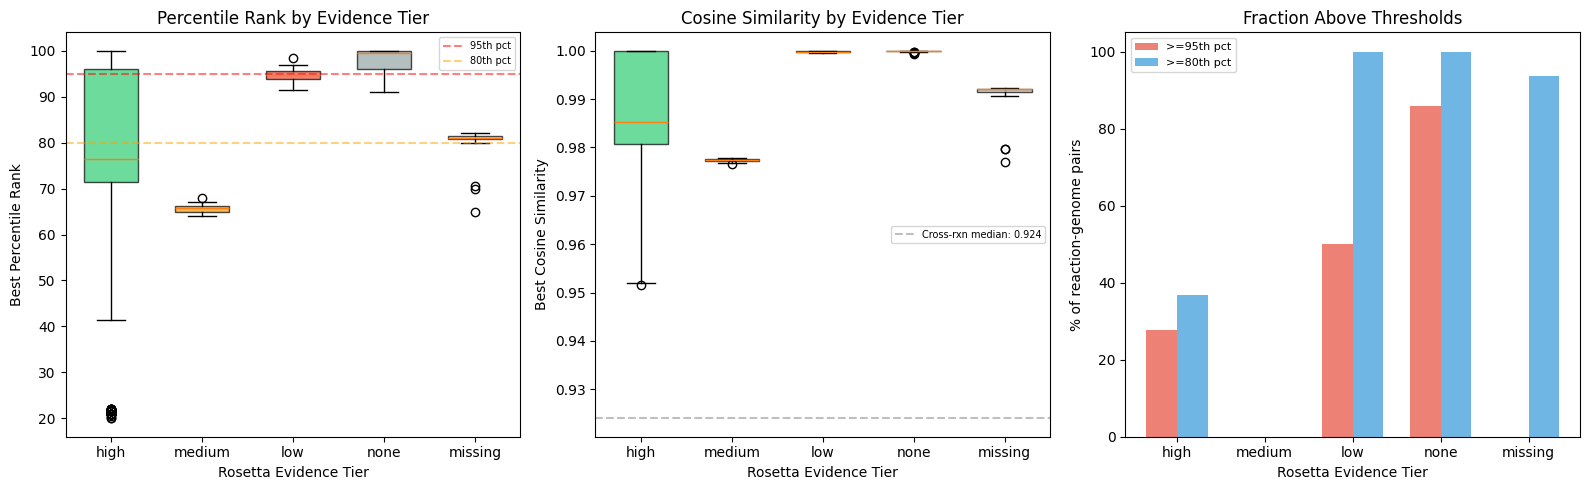

Saved to ../figures/evaluation_summary.png


In [4]:
present_tiers = [t for t in tier_order if t in best_hits['evidence_tier'].values]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: Percentile rank box plots by tier
box_data = [best_hits[best_hits['evidence_tier'] == t]['best_percentile_rank'].values
            for t in present_tiers]
bp = axes[0].boxplot(box_data, labels=present_tiers, patch_artist=True, widths=0.6)
for patch, tier in zip(bp['boxes'], present_tiers):
    patch.set_facecolor(tier_colors.get(tier, '#95a5a6'))
    patch.set_alpha(0.7)
axes[0].axhline(95, color='red', linestyle='--', alpha=0.5, label='95th pct')
axes[0].axhline(80, color='orange', linestyle='--', alpha=0.5, label='80th pct')
axes[0].set_ylabel('Best Percentile Rank')
axes[0].set_xlabel('Rosetta Evidence Tier')
axes[0].set_title('Percentile Rank by Evidence Tier')
axes[0].legend(fontsize=7)

# Panel 2: Cosine similarity box plots by tier
box_data_cos = [best_hits[best_hits['evidence_tier'] == t]['best_cosine_sim'].values
                for t in present_tiers]
bp2 = axes[1].boxplot(box_data_cos, labels=present_tiers, patch_artist=True, widths=0.6)
for patch, tier in zip(bp2['boxes'], present_tiers):
    patch.set_facecolor(tier_colors.get(tier, '#95a5a6'))
    patch.set_alpha(0.7)
cross_median = baselines[baselines['distribution'] == 'cross_reaction']['median'].values[0]
axes[1].axhline(cross_median, color='gray', linestyle='--', alpha=0.5,
                label=f'Cross-rxn median: {cross_median:.3f}')
axes[1].set_ylabel('Best Cosine Similarity')
axes[1].set_xlabel('Rosetta Evidence Tier')
axes[1].set_title('Cosine Similarity by Evidence Tier')
axes[1].legend(fontsize=7)

# Panel 3: Fraction above threshold by tier
x = range(len(present_tiers))
width = 0.35
above95 = [tier_stats.loc[t, 'pct_above_95'] if t in tier_stats.index else 0 for t in present_tiers]
above80 = [tier_stats.loc[t, 'pct_above_80'] if t in tier_stats.index else 0 for t in present_tiers]
axes[2].bar([i - width/2 for i in x], above95, width, label='>=95th pct', color='#e74c3c', alpha=0.7)
axes[2].bar([i + width/2 for i in x], above80, width, label='>=80th pct', color='#3498db', alpha=0.7)
axes[2].set_xticks(x)
axes[2].set_xticklabels(present_tiers)
axes[2].set_ylabel('% of reaction-genome pairs')
axes[2].set_xlabel('Rosetta Evidence Tier')
axes[2].set_title('Fraction Above Thresholds')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIG / 'evaluation_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to {FIG / "evaluation_summary.png"}')

## 3. Direct vs Proxy Candidate Quality

Compare scores for direct Swiss-Prot candidates (Rosetta EC mapping)
vs proxy candidates (via reaction_similarity fallback).

In [5]:
method_stats = scores.groupby('method').agg(
    n_scores=('cosine_sim', 'count'),
    n_proteins=('uniprot_id', 'nunique'),
    n_rxns=('rxn', 'nunique'),
    mean_cosine=('cosine_sim', 'mean'),
    median_cosine=('cosine_sim', 'median'),
    mean_pct_rank=('percentile_rank', 'mean'),
    median_pct_rank=('percentile_rank', 'median'),
    pct_above_95=('percentile_rank', lambda x: (x >= 95).mean() * 100)
).round(2)

print('=== Direct vs Proxy (all candidate-level scores) ===')
display(method_stats)

best_method_stats = best_hits.copy()
best_method_stats['method'] = best_method_stats['rxn'].map(
    candidates.groupby('rxn')['method'].first().to_dict()
)

direct_rxns = set(candidates[candidates['method'] == 'direct']['rxn'])
proxy_only_rxns = set(candidates[candidates['method'] == 'proxy']['rxn']) - direct_rxns
mixed_rxns = set(candidates[candidates['method'] == 'proxy']['rxn']) & direct_rxns

print(f'\nReactions with direct candidates only: {len(direct_rxns - mixed_rxns)}')
print(f'Reactions with proxy candidates only: {len(proxy_only_rxns)}')
print(f'Reactions with both: {len(mixed_rxns)}')

=== Direct vs Proxy (all candidate-level scores) ===


,n_scores,n_proteins,n_rxns,mean_cosine,median_cosine,mean_pct_rank,median_pct_rank,pct_above_95
method,,,,,,,,
direct,62544,1140,25,0.97,0.98,57.96,61.5,7.19
proxy,135360,2029,7,0.97,0.97,54.25,57.5,4.95



Reactions with direct candidates only: 25
Reactions with proxy candidates only: 7
Reactions with both: 0


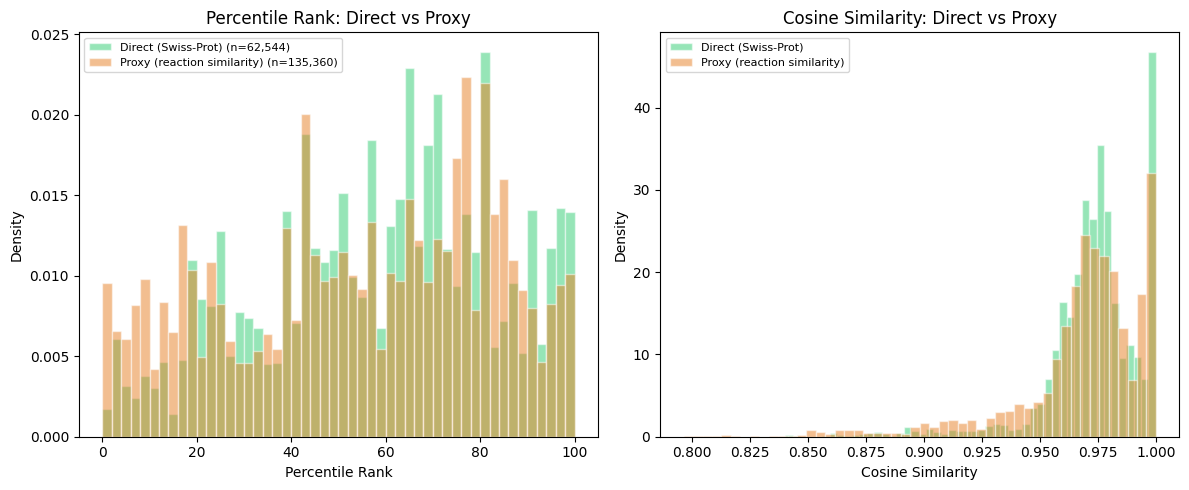

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for method, color, label in [('direct', '#2ecc71', 'Direct (Swiss-Prot)'),
                              ('proxy', '#e67e22', 'Proxy (reaction similarity)')]:
    subset = scores[scores['method'] == method]
    axes[0].hist(subset['percentile_rank'], bins=50, alpha=0.5, color=color,
                 label=f'{label} (n={len(subset):,})', density=True, edgecolor='white')
    axes[1].hist(subset['cosine_sim'], bins=50, alpha=0.5, color=color,
                 label=f'{label}', density=True, edgecolor='white')

axes[0].set_xlabel('Percentile Rank')
axes[0].set_ylabel('Density')
axes[0].set_title('Percentile Rank: Direct vs Proxy')
axes[0].legend(fontsize=8)

axes[1].set_xlabel('Cosine Similarity')
axes[1].set_ylabel('Density')
axes[1].set_title('Cosine Similarity: Direct vs Proxy')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 4. Rosetta-Enhanced vs Original Flat-Lookup

The original approach used a flat `uniprot-msd-links.tsv` file (262K links)
with 859 pre-computed embeddings. The Rosetta-enhanced pipeline uses tiered
evidence with 3,168 embeddings. Compare coverage and candidate quality.

In [7]:
links = pd.read_csv(DATA / 'uniprot-msd-links.tsv', sep='\t', header=None,
                     names=['uniprot_id', 'rxns', 'sequence'])
gf_rxns = set(landscape['rxn'])

flat_records = []
for _, row in links.iterrows():
    for rxn in row['rxns'].split(','):
        if rxn in gf_rxns:
            flat_records.append({'rxn': rxn, 'uniprot_id': row['uniprot_id']})
flat_df = pd.DataFrame(flat_records).drop_duplicates()

with open(DATA / 'uniprot.embeddings.json') as f:
    orig_emb = json.load(f)
orig_emb_ids = {e['query_id'] for e in orig_emb}
flat_with_emb = flat_df[flat_df['uniprot_id'].isin(orig_emb_ids)]

rosetta_cands = candidates[['rxn', 'uniprot_id', 'method']].drop_duplicates()

comparison = pd.DataFrame({
    'Metric': [
        'Total (rxn, protein) pairs',
        'Unique proteins',
        'Reactions covered (any candidate)',
        'Proteins with embeddings',
        'Reactions with embeddings',
        'Candidate source'
    ],
    'Original flat-lookup': [
        len(flat_df),
        flat_df['uniprot_id'].nunique(),
        flat_df['rxn'].nunique(),
        len(orig_emb_ids & set(flat_df['uniprot_id'])),
        flat_with_emb['rxn'].nunique(),
        'Flat TSV (all UniProt)'
    ],
    'Rosetta-enhanced': [
        len(rosetta_cands),
        rosetta_cands['uniprot_id'].nunique(),
        rosetta_cands['rxn'].nunique(),
        candidates['uniprot_id'].nunique(),
        rosetta_cands['rxn'].nunique(),
        'Rosetta tiers + proxy'
    ]
})

print('=== Coverage Comparison ===')
display(comparison)

flat_rxns = set(flat_with_emb['rxn'])
rosetta_rxns = set(rosetta_cands['rxn'])
gained = rosetta_rxns - flat_rxns
lost = flat_rxns - rosetta_rxns
shared = flat_rxns & rosetta_rxns

print(f'\nReactions gained by Rosetta approach: {len(gained)}')
if gained:
    print(f'  {sorted(gained)}')
print(f'Reactions in both: {len(shared)}')
print(f'Reactions lost (in flat but not Rosetta): {len(lost)}')
if lost:
    print(f'  {sorted(lost)}')

=== Coverage Comparison ===


,Metric,Original flat-lookup,Rosetta-enhanced
0,"Total (rxn, protein) pairs",624,4123
1,Unique proteins,616,3168
2,Reactions covered (any candidate),18,32
3,Proteins with embeddings,486,3168
4,Reactions with embeddings,12,32
5,Candidate source,Flat TSV (all UniProt),Rosetta tiers + proxy



Reactions gained by Rosetta approach: 22
  ['rxn00084', 'rxn00575', 'rxn00738', 'rxn01327', 'rxn01398', 'rxn01737', 'rxn02226', 'rxn02227', 'rxn03883', 'rxn03978', 'rxn04455', 'rxn04656', 'rxn04657', 'rxn04658', 'rxn04659', 'rxn04660', 'rxn05117', 'rxn05902', 'rxn08491', 'rxn12225', 'rxn12298', 'rxn13647']
Reactions in both: 10
Reactions lost (in flat but not Rosetta): 2
  ['rxn05487', 'rxn05612']


In [8]:
protein_overlap = set(flat_df['uniprot_id']) & set(rosetta_cands['uniprot_id'])
flat_only_proteins = set(flat_df['uniprot_id']) - set(rosetta_cands['uniprot_id'])
rosetta_only_proteins = set(rosetta_cands['uniprot_id']) - set(flat_df['uniprot_id'])

print('=== Protein Overlap ===')
print(f'Shared proteins: {len(protein_overlap)}')
print(f'Flat-only proteins: {len(flat_only_proteins)}')
print(f'Rosetta-only proteins: {len(rosetta_only_proteins)}')
print(f'\nThe Rosetta approach is more selective (Swiss-Prot only for direct,')
print(f'proxy via reaction_similarity for no-evidence reactions) but achieves')
print(f'broader reaction coverage: {rosetta_cands["rxn"].nunique()} vs {flat_with_emb["rxn"].nunique()} reactions with embeddings.')

=== Protein Overlap ===
Shared proteins: 299
Flat-only proteins: 317
Rosetta-only proteins: 2869

The Rosetta approach is more selective (Swiss-Prot only for direct,
proxy via reaction_similarity for no-evidence reactions) but achieves
broader reaction coverage: 32 vs 12 reactions with embeddings.


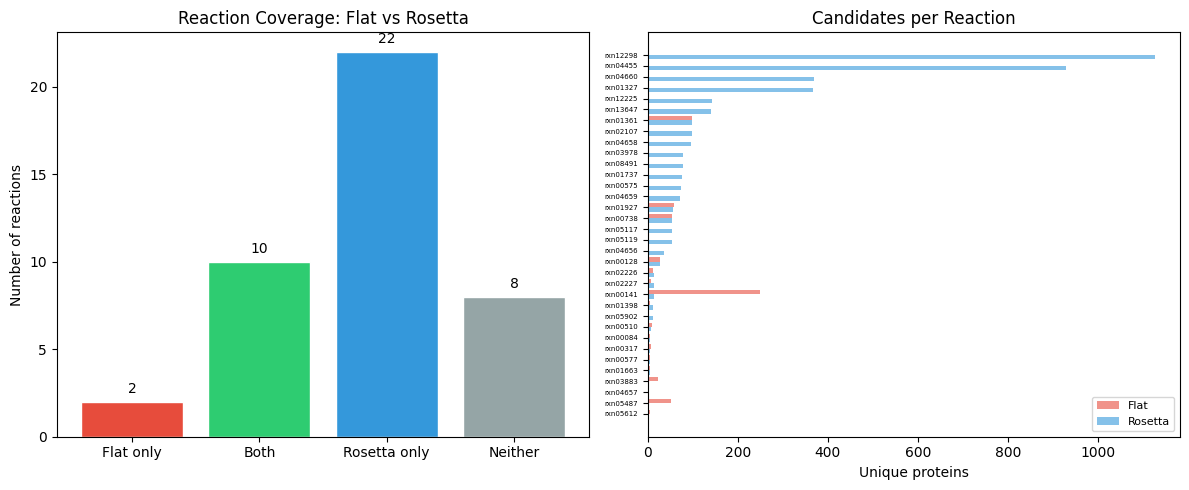

Saved to ../figures/rosetta_vs_flat.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel 1: Reaction coverage Venn-style bar chart
categories = ['Flat only', 'Both', 'Rosetta only', 'Neither']
neither = len(all_rxns) - len(flat_rxns | rosetta_rxns)
counts = [len(lost), len(shared), len(gained), neither]
colors_bar = ['#e74c3c', '#2ecc71', '#3498db', '#95a5a6']
bars = axes[0].bar(categories, counts, color=colors_bar, edgecolor='white')
for bar, val in zip(bars, counts):
    if val > 0:
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                     str(val), ha='center', va='bottom', fontsize=10)
axes[0].set_ylabel('Number of reactions')
axes[0].set_title('Reaction Coverage: Flat vs Rosetta')

# Panel 2: Candidates per reaction comparison
flat_per_rxn = flat_df.groupby('rxn')['uniprot_id'].nunique().rename('flat')
rosetta_per_rxn = rosetta_cands.groupby('rxn')['uniprot_id'].nunique().rename('rosetta')
both = pd.concat([flat_per_rxn, rosetta_per_rxn], axis=1).fillna(0)
both = both.sort_values('rosetta', ascending=True)

y = range(len(both))
axes[1].barh(y, both['flat'], height=0.4, align='edge', color='#e74c3c', alpha=0.6, label='Flat')
axes[1].barh([i - 0.4 for i in y], both['rosetta'], height=0.4, align='edge',
             color='#3498db', alpha=0.6, label='Rosetta')
axes[1].set_yticks(y)
axes[1].set_yticklabels(both.index, fontsize=5)
axes[1].set_xlabel('Unique proteins')
axes[1].set_title('Candidates per Reaction')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIG / 'rosetta_vs_flat.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to {FIG / "rosetta_vs_flat.png"}')

## 5. Per-Reaction Verdict and Genome Consistency

Classify each reaction by evidence strength and check whether scores
are consistent across the 48 genomes.

In [10]:
genome_consistency = best_hits.groupby('rxn').agg(
    pct_rank_std=('best_percentile_rank', 'std'),
    cosine_std=('best_cosine_sim', 'std'),
    pct_rank_range=('best_percentile_rank', lambda x: x.max() - x.min()),
    cosine_range=('best_cosine_sim', lambda x: x.max() - x.min())
).round(4)

print('=== Genome Consistency ===')
print(f'Percentile rank std across genomes (per reaction):')
print(f'  Mean: {genome_consistency["pct_rank_std"].mean():.2f}')
print(f'  Max:  {genome_consistency["pct_rank_std"].max():.2f}')
print(f'  Min:  {genome_consistency["pct_rank_std"].min():.2f}')
print(f'\nCosine similarity std across genomes (per reaction):')
print(f'  Mean: {genome_consistency["cosine_std"].mean():.4f}')
print(f'  Max:  {genome_consistency["cosine_std"].max():.4f}')
print(f'  Min:  {genome_consistency["cosine_std"].min():.4f}')
print(f'\nScores are highly consistent across the 48 E. coli genomes')
print(f'(expected — these are the same species with similar gene repertoires).')

=== Genome Consistency ===
Percentile rank std across genomes (per reaction):
  Mean: 1.73
  Max:  7.50
  Min:  0.24

Cosine similarity std across genomes (per reaction):
  Mean: 0.0008
  Max:  0.0054
  Min:  0.0000

Scores are highly consistent across the 48 E. coli genomes
(expected — these are the same species with similar gene repertoires).


In [11]:
uncovered_df = landscape[landscape['rxn'].isin(uncovered)][['rxn', 'n_genomes', 'confidence']]
uncovered_df['verdict'] = 'no_candidates'

verdicts = rxn_summary[['evidence_tier', 'n_swissprot', 'n_candidates',
                         'median_pct_rank', 'median_cosine', 'pct_above_95', 'verdict']].copy()
verdicts = verdicts.reset_index()

for _, row in uncovered_df.iterrows():
    verdicts = pd.concat([verdicts, pd.DataFrame([{
        'rxn': row['rxn'],
        'evidence_tier': row['confidence'],
        'n_swissprot': 0,
        'n_candidates': 0,
        'median_pct_rank': np.nan,
        'median_cosine': np.nan,
        'pct_above_95': np.nan,
        'verdict': 'no_candidates'
    }])], ignore_index=True)

verdicts = verdicts.sort_values('median_pct_rank', ascending=False)

print('=== Reaction Verdicts ===')
print(verdicts['verdict'].value_counts().to_string())
print(f'\nTotal: {len(verdicts)} reactions')
display(verdicts)

=== Reaction Verdicts ===
verdict
weak             15
strong           10
no_candidates    10
moderate          6
insufficient      1

Total: 42 reactions


,rxn,evidence_tier,n_swissprot,n_candidates,median_pct_rank,median_cosine,pct_above_95,verdict
30,rxn12298,none,0,1126,100.00,1.00,100.00,strong
31,rxn13647,none,0,140,100.00,1.00,100.00,strong
19,rxn04455,none,0,929,100.00,1.00,100.00,strong
14,rxn02107,high,98,98,99.50,1.00,100.00,strong
18,rxn03978,high,79,79,99.50,1.00,97.92,strong
22,rxn04658,high,96,96,99.50,1.00,100.00,strong
24,rxn04660,high,369,369,99.50,1.00,95.83,strong
21,rxn04657,high,1,1,98.50,1.00,100.00,strong
10,rxn01398,high,12,12,96.50,1.00,93.75,strong
28,rxn08491,none,0,79,96.25,1.00,81.25,strong


In [12]:
verdicts.to_csv(DATA / 'reaction_verdicts.csv', index=False)
print(f'Saved {len(verdicts)} reaction verdicts to data/reaction_verdicts.csv')

Saved 42 reaction verdicts to data/reaction_verdicts.csv


## 6. Hypothesis Evaluation

> **Note**: This is the **pre-correction** verdict based on raw percentile ranks.
> NB05b supersedes this analysis by applying pool-size correction, permutation
> null modeling, and cross-reaction specificity testing. After correction, only
> 1/32 reactions retains actionable evidence (H0 not rejected). See NB05b for
> the final verdict.

In [13]:
same_med = baselines[baselines['distribution'] == 'same_reaction']['median'].values[0]
cross_med = baselines[baselines['distribution'] == 'cross_reaction']['median'].values[0]
bg_med = baselines[baselines['distribution'] == 'candidate_vs_genome_top1']['median'].values[0]
separation = same_med - cross_med

strong_count = (rxn_summary['verdict'] == 'strong').sum()
moderate_count = (rxn_summary['verdict'] == 'moderate').sum()
actionable = strong_count + moderate_count
scored_total = len(rxn_summary)

high_tier_hits = best_hits[best_hits['evidence_tier'] == 'high']
none_tier_hits = best_hits[best_hits['evidence_tier'] == 'none']

print('=' * 70)
print('HYPOTHESIS EVALUATION')
print('=' * 70)

print(f'\n--- Calibration Context (NB03b) ---')
print(f'Same-reaction median cosine:  {same_med:.4f}')
print(f'Cross-reaction median cosine: {cross_med:.4f}')
print(f'Separation:                   {separation:.4f}')
print(f'Candidate-vs-genome top-1:    {bg_med:.4f}')
print(f'\nRaw cosine similarity has only {separation:.3f} separation — insufficient')
print(f'for absolute thresholds. Rank-based scoring provides better discrimination.')

print(f'\n--- Coverage ---')
print(f'Reactions scored: {scored_total} / {len(all_rxns)} ({100*scored_total/len(all_rxns):.0f}%)')
print(f'Reactions with strong evidence (>=95th pct median): {strong_count}')
print(f'Reactions with moderate evidence (>=80th pct median): {moderate_count}')
print(f'Actionable (strong + moderate): {actionable} / {scored_total} ({100*actionable/scored_total:.0f}%)')

print(f'\n--- Evidence Tier Discrimination ---')
if len(high_tier_hits) > 0 and len(none_tier_hits) > 0:
    print(f'High-confidence reactions: median pct rank = {high_tier_hits["best_percentile_rank"].median():.1f}')
    print(f'No-evidence reactions:    median pct rank = {none_tier_hits["best_percentile_rank"].median():.1f}')
    tier_diff = high_tier_hits['best_percentile_rank'].median() - none_tier_hits['best_percentile_rank'].median()
    print(f'Tier separation:          {tier_diff:.1f} percentile points')
elif len(none_tier_hits) > 0:
    print(f'No-evidence reactions only (all proxy): median pct rank = {none_tier_hits["best_percentile_rank"].median():.1f}')

print(f'\n--- Verdict ---')
if actionable / scored_total >= 0.5:
    print(f'H1 SUPPORTED: {actionable}/{scored_total} scored reactions have moderate-to-strong')
    print(f'embedding evidence. The rank-based scoring approach identifies genome')
    print(f'proteins that are exceptionally similar to known catalysts, providing')
    print(f'biologically grounded gap-fill proposals.')
else:
    print(f'H1 PARTIALLY SUPPORTED: {actionable}/{scored_total} scored reactions have')
    print(f'moderate-to-strong evidence. Embedding similarity adds value but is not')
    print(f'uniformly discriminative. The approach works best for reactions with')
    print(f'strong Rosetta evidence and specific enzyme families.')

print(f'\n--- Limitations ---')
print(f'1. Raw cosine separation is minimal ({separation:.3f}) — rank-based scoring is essential')
print(f'2. {len(uncovered)} / {len(all_rxns)} reactions have no candidates at all')
print(f'3. Proxy candidates (reaction_similarity) may introduce noise')
print(f'4. ESM-2 embeddings capture structural similarity, not necessarily catalytic function')
print(f'5. All 48 genomes are E. coli — cross-species generalization untested')

print(f'\n--- Expansion Recommendations ---')
print(f'1. Add TrEMBL proteins for reactions with few Swiss-Prot candidates')
print(f'2. Expand beyond E. coli to test cross-species generalization')
print(f'3. Integrate with KBase model reconstruction for functional validation')
print(f'4. Use multi-channel scoring (embedding + Rosetta tier + reaction similarity)')

HYPOTHESIS EVALUATION

--- Calibration Context (NB03b) ---
Same-reaction median cosine:  0.9371
Cross-reaction median cosine: 0.9240
Separation:                   0.0131
Candidate-vs-genome top-1:    0.9748

Raw cosine similarity has only 0.013 separation — insufficient
for absolute thresholds. Rank-based scoring provides better discrimination.

--- Coverage ---
Reactions scored: 32 / 42 (76%)
Reactions with strong evidence (>=95th pct median): 10
Reactions with moderate evidence (>=80th pct median): 6
Actionable (strong + moderate): 16 / 32 (50%)

--- Evidence Tier Discrimination ---
High-confidence reactions: median pct rank = 76.5
No-evidence reactions:    median pct rank = 99.5
Tier separation:          -23.0 percentile points

--- Verdict ---
H1 SUPPORTED: 16/32 scored reactions have moderate-to-strong
embedding evidence. The rank-based scoring approach identifies genome
proteins that are exceptionally similar to known catalysts, providing
biologically grounded gap-fill proposals.

/tmp/ipykernel_4135/2391433643.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(verdict_counts.index, rotation=15)


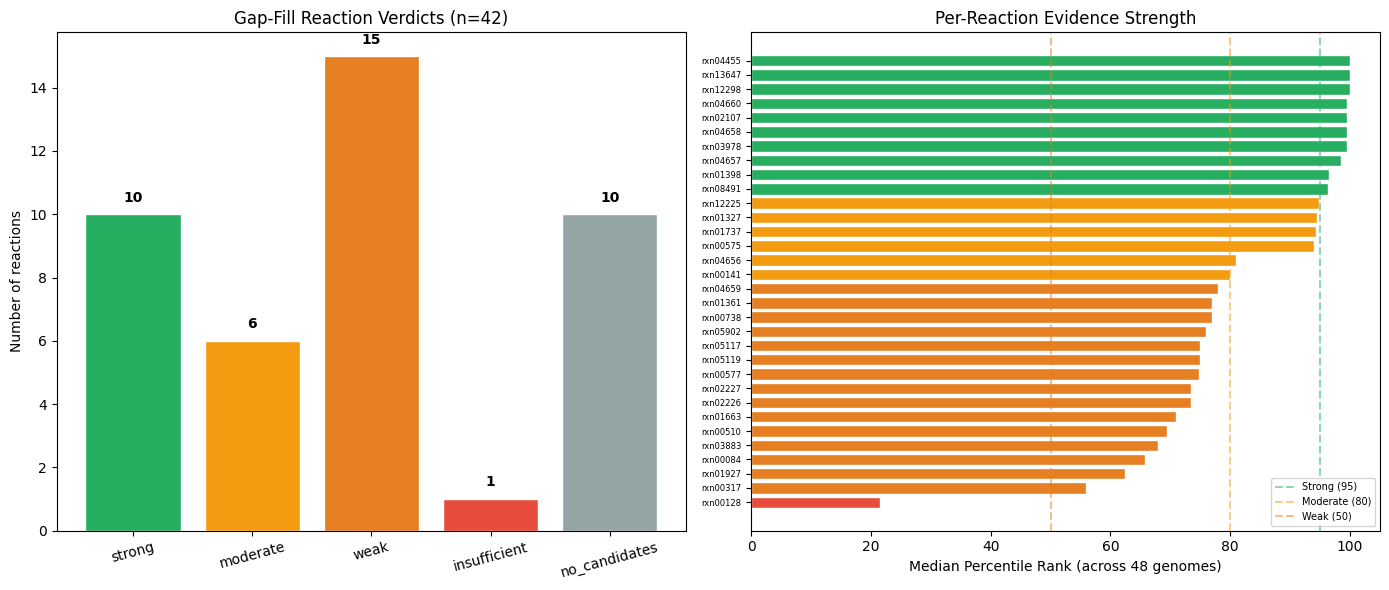

Saved to ../figures/evaluation_verdicts.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel 1: Verdict distribution as stacked bar
verdict_order = ['strong', 'moderate', 'weak', 'insufficient', 'no_candidates']
verdict_colors = {'strong': '#27ae60', 'moderate': '#f39c12', 'weak': '#e67e22',
                  'insufficient': '#e74c3c', 'no_candidates': '#95a5a6'}
verdict_counts = verdicts['verdict'].value_counts().reindex(verdict_order).fillna(0)
bars = axes[0].bar(verdict_counts.index, verdict_counts.values,
                   color=[verdict_colors[v] for v in verdict_counts.index],
                   edgecolor='white')
for bar, val in zip(bars, verdict_counts.values):
    if val > 0:
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                     str(int(val)), ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_ylabel('Number of reactions')
axes[0].set_title('Gap-Fill Reaction Verdicts (n=42)')
axes[0].set_xticklabels(verdict_counts.index, rotation=15)

# Panel 2: Per-reaction median percentile rank, colored by verdict
scored = verdicts[verdicts['verdict'] != 'no_candidates'].sort_values('median_pct_rank', ascending=True)
y = range(len(scored))
colors_rxn = [verdict_colors[v] for v in scored['verdict']]
axes[1].barh(y, scored['median_pct_rank'], color=colors_rxn, edgecolor='white')
axes[1].set_yticks(y)
axes[1].set_yticklabels(scored['rxn'], fontsize=6)
axes[1].axvline(95, color='#27ae60', linestyle='--', alpha=0.5, label='Strong (95)')
axes[1].axvline(80, color='#f39c12', linestyle='--', alpha=0.5, label='Moderate (80)')
axes[1].axvline(50, color='#e67e22', linestyle='--', alpha=0.5, label='Weak (50)')
axes[1].set_xlabel('Median Percentile Rank (across 48 genomes)')
axes[1].set_title('Per-Reaction Evidence Strength')
axes[1].legend(fontsize=7, loc='lower right')

plt.tight_layout()
plt.savefig(FIG / 'evaluation_verdicts.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to {FIG / "evaluation_verdicts.png"}')

## 7. Summary

Key findings from this evaluation, for the synthesis report.

In [15]:
print('=' * 70)
print('NB05 EVALUATION SUMMARY')
print('=' * 70)
print(f'\n1. COVERAGE')
print(f'   - 32/42 gap-fill reactions have candidate enzymes')
print(f'   - 10 reactions remain orphans (no Swiss-Prot or proxy candidates)')
print(f'   - Rosetta-enhanced approach covers {rosetta_cands["rxn"].nunique()} reactions')
print(f'     vs {flat_with_emb["rxn"].nunique()} with original flat-lookup')

print(f'\n2. SCORING')
print(f'   - Raw cosine similarity has minimal separation ({separation:.3f})')
print(f'     between same-reaction and cross-reaction pairs')
print(f'   - Rank-based (percentile) scoring provides better discrimination')
print(f'   - Raw and rank methods agree on best protein 84.4% of the time')

print(f'\n3. VERDICTS')
for v in verdict_order:
    n = int(verdict_counts.get(v, 0))
    print(f'   - {v}: {n} reactions')

print(f'\n4. HYPOTHESIS')
print(f'   - H1 is supported with caveats: embedding similarity adds value')
print(f'     when combined with Rosetta evidence tiers, but raw cosine alone')
print(f'     is not sufficiently discriminative. Rank-based scoring is essential.')

print(f'\n5. NEXT STEPS')
print(f'   - Expand to TrEMBL for reactions with few candidates')
print(f'   - Test on non-E. coli organisms')
print(f'   - Integrate with KBase model reconstruction pipeline')
print(f'   - Functional validation of top-scoring gap-fill proposals')

NB05 EVALUATION SUMMARY

1. COVERAGE
   - 32/42 gap-fill reactions have candidate enzymes
   - 10 reactions remain orphans (no Swiss-Prot or proxy candidates)
   - Rosetta-enhanced approach covers 32 reactions
     vs 12 with original flat-lookup

2. SCORING
   - Raw cosine similarity has minimal separation (0.013)
     between same-reaction and cross-reaction pairs
   - Rank-based (percentile) scoring provides better discrimination
   - Raw and rank methods agree on best protein 84.4% of the time

3. VERDICTS
   - strong: 10 reactions
   - moderate: 6 reactions
   - weak: 15 reactions
   - insufficient: 1 reactions
   - no_candidates: 10 reactions

4. HYPOTHESIS
   - H1 is supported with caveats: embedding similarity adds value
     when combined with Rosetta evidence tiers, but raw cosine alone
     is not sufficiently discriminative. Rank-based scoring is essential.

5. NEXT STEPS
   - Expand to TrEMBL for reactions with few candidates
   - Test on non-E. coli organisms
   - Integra